In [1]:
# Core Data Manipulation Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:

walmart_df = pd.read_csv('/content/sample_data/Walmart (1).csv')

retail_df = pd.read_csv('/content/sample_data/OnlineRetail (3).csv', encoding='unicode_escape')

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [4]:
# Inspect Walmart Data
print("=== Walmart Sales Data ===")
print(f"Shape: {walmart_df.shape}")
print("\nData Types and Missing Values:")
walmart_df.info()
display(walmart_df.head())

print("\n" + "="*1000 + "\n")

# Inspect Online Retail Data
print("=== Online Retail Data ===")
print(f"Shape: {retail_df.shape}")
print("\nData Types and Missing Values:")
retail_df.info()
display(retail_df.head())

=== Walmart Sales Data ===
Shape: (6435, 8)

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106




=== Online Retail Data ===
Shape: (541909, 8)

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
# 1. Temporal Parsing Convert 'Date' to datetime objects. (Assuming standard
# Walmart dataset date format)
walmart_df['Date'] = pd.to_datetime(walmart_df['Date'], dayfirst=True)

# 2. Feature Extraction (Explicit seasonal time components)
walmart_df['Year'] = walmart_df['Date'].dt.year
walmart_df['Month'] = walmart_df['Date'].dt.month
walmart_df['WeekOfYear'] = walmart_df['Date'].dt.isocalendar().week

# 3. Data Alignment
# Chronologically sort records by Store and Date to ensure sequence integrity
walmart_df = walmart_df.sort_values(by=['Store', 'Date']).reset_index(drop=True)

# 4. Macroeconomic Verification
print("=== Walmart Pre-processing Complete ===")
print("Missing values in macroeconomic features:")
print(walmart_df[['CPI', 'Unemployment']].isnull().sum())
display(walmart_df[['Store', 'Date', 'Weekly_Sales', 'Year', 'Month', 'WeekOfYear']].head())

=== Walmart Pre-processing Complete ===
Missing values in macroeconomic features:
CPI             0
Unemployment    0
dtype: int64


,Store,Date,Weekly_Sales,Year,Month,WeekOfYear
0,1,2010-02-05,1643690.90,2010,2,5
1,1,2010-02-12,1641957.44,2010,2,6
2,1,2010-02-19,1611968.17,2010,2,7
3,1,2010-02-26,1409727.59,2010,2,8
4,1,2010-03-05,1554806.68,2010,3,9


In [7]:
# 1. Identity Pruning
# Remove rows with null CustomerID
retail_df = retail_df.dropna(subset=['CustomerID'])

# 2. Anomaly & Return Mitigation
# Filter out transactions where Quantity <= 0 or UnitPrice <= 0
retail_df = retail_df[(retail_df['Quantity'] > 0) & (retail_df['UnitPrice'] > 0)]

# 3. Monetary Computation
# Synthesize the new column TotalSpend
retail_df['TotalSpend'] = retail_df['Quantity'] * retail_df['UnitPrice']

# 4. Temporal Parsing
# Convert InvoiceDate to datetime for Recency calculation in the next stage
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])

print("=== Online Retail Pre-processing Complete ===")
print(f"Cleaned Retail Data Shape: {retail_df.shape}")
display(retail_df[['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'TotalSpend', 'CustomerID']].head())

=== Online Retail Pre-processing Complete ===
Cleaned Retail Data Shape: (397884, 9)


,InvoiceNo,StockCode,Quantity,UnitPrice,TotalSpend,CustomerID
0,536365,85123A,6,2.55,15.30,17850.0
1,536365,71053,6,3.39,20.34,17850.0
2,536365,84406B,8,2.75,22.00,17850.0
3,536365,84029G,6,3.39,20.34,17850.0
4,536365,84029E,6,3.39,20.34,17850.0


In [9]:
import datetime as dt

# 1. Establish the Baseline Date
# (Set to 1 day after the last transaction in the dataset to avoid a Recency of 0 days)
baseline_date = retail_df['InvoiceDate'].max() + dt.timedelta(days=1)

# 2. Aggregate Transactions by CustomerID
rfm_df = retail_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (baseline_date - x.max()).days,  # Recency: Days since last purchase
    'InvoiceNo': 'nunique',                                  # Frequency: Count of unique invoices
    'TotalSpend': 'sum'                                      # Monetary: Total money spent
}).reset_index()

# 3. Rename columns for clarity
rfm_df.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSpend': 'Monetary'
}, inplace=True)

print("=== RFM Matrix Engineered ===")
print(f"Total Unique Customers: {rfm_df.shape[0]}")
display(rfm_df.head())

=== RFM Matrix Engineered ===
Total Unique Customers: 4338


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [10]:
from sklearn.preprocessing import StandardScaler

# 1. Apply Natural Log Transformation (np.log1p)
# We use log1p instead of log to safely handle any potential zeros
rfm_log = rfm_df.copy()
rfm_features = ['Recency', 'Frequency', 'Monetary']

for col in rfm_features:
    rfm_log[col] = np.log1p(rfm_df[col])

# 2. Standard Normalization
scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm_log[rfm_features])

# 3. Convert the scaled array back to a DataFrame for modeling
rfm_scaled = pd.DataFrame(rfm_scaled_array, columns=rfm_features, index=rfm_df.index)

print("=== Data Scaling Complete ===")
display(rfm_scaled.head())

=== Data Scaling Complete ===


,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.706225
1,-2.038734,1.074425,1.411843
2,0.373104,0.386304,0.716489
3,-0.623086,-0.955214,0.698739
4,1.424558,-0.955214,-0.618962


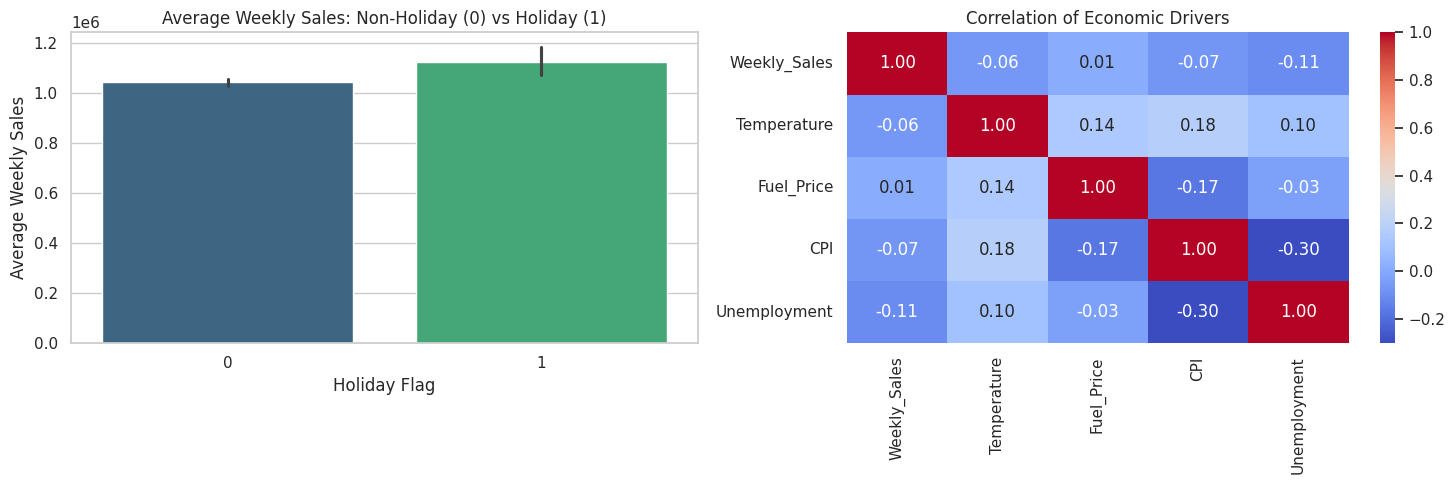

In [15]:
# Create a figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Average Weekly Sales (Holiday vs Non-Holiday)
sns.barplot(x='Holiday_Flag', y='Weekly_Sales', data=walmart_df, ax=axes[0], palette='viridis')
axes[0].set_title('Average Weekly Sales: Non-Holiday (0) vs Holiday (1)')
axes[0].set_xlabel('Holiday Flag')
axes[0].set_ylabel('Average Weekly Sales')

# Plot 2: Correlation Heatmap of Economic Drivers
# Select only numeric features for correlation
numeric_features = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
correlation_matrix = walmart_df[numeric_features].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Correlation of Economic Drivers')

# Finalize layout and render
plt.tight_layout()
plt.show()

Calculating clusters. This may take a few seconds...


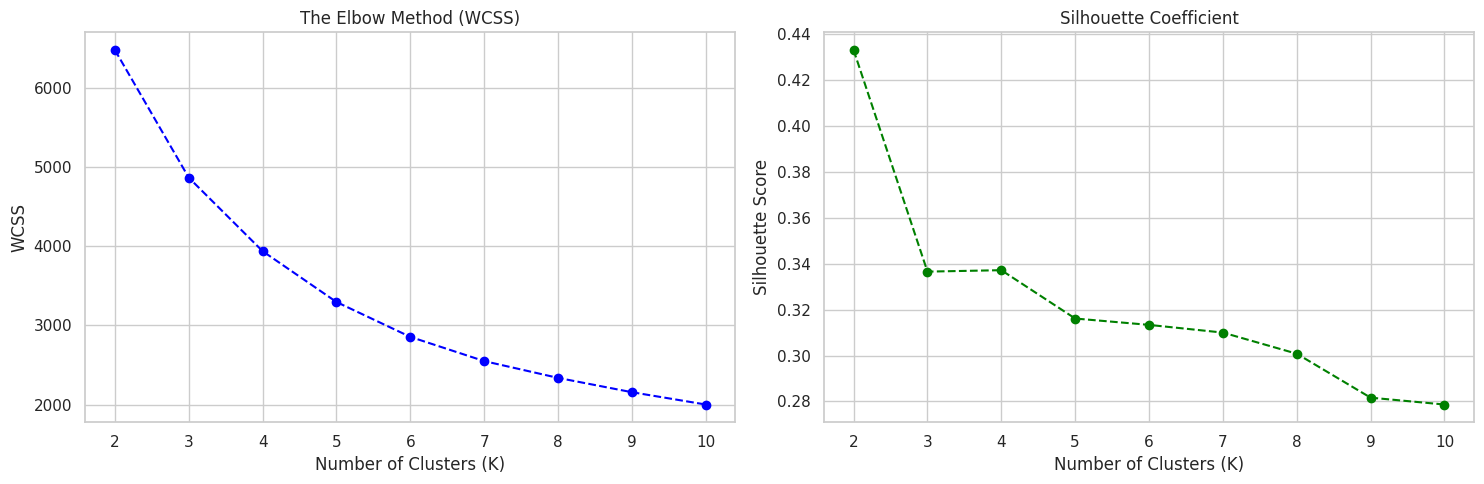

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Iterate to find optimal K
wcss = []
silhouette_scores = []
K_range = range(2, 11)

print("Calculating clusters. This may take a few seconds...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)

    # Within-Cluster Sum of Squares (WCSS)
    wcss.append(kmeans.inertia_)

    # Silhouette Score
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

# 2. Plotting the Evaluation Metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Plot
axes[0].plot(K_range, wcss, marker='o', linestyle='--', color='blue')
axes[0].set_title('The Elbow Method (WCSS)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS')

# Silhouette Plot
axes[1].plot(K_range, silhouette_scores, marker='o', linestyle='--', color='green')
axes[1].set_title('Silhouette Coefficient')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

=== Customer Behavioral Segments ===


,Avg Recency (Days),Avg Frequency (Invoices),Avg Monetary ($),Total Customers
Cluster,,,,
0,17.06,13.34,7905.44,770
1,167.36,1.35,362.54,1872
2,44.21,3.38,1265.06,1696


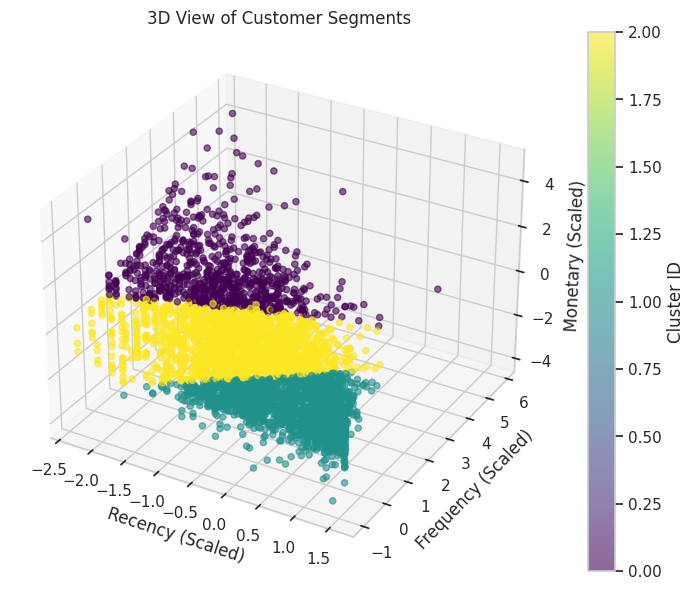

In [17]:
# 1. Train final K-Means model
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Assign cluster labels back to the ORIGINAL (unscaled) RFM dataframe for interpretable numbers
rfm_df['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

# 2. Profile the Segments
cluster_profile = rfm_df.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

# Rename the columns for a clean display table
cluster_profile.columns = ['Avg Recency (Days)', 'Avg Frequency (Invoices)', 'Avg Monetary ($)', 'Total Customers']

print("=== Customer Behavioral Segments ===")
display(cluster_profile)

# 3. Quick 3D Visualization of the Clusters
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot using the log-scaled data for better visual distribution
scatter = ax.scatter(rfm_scaled['Recency'], rfm_scaled['Frequency'], rfm_scaled['Monetary'],
                     c=rfm_df['Cluster'], cmap='viridis', alpha=0.6)

ax.set_title('3D View of Customer Segments')
ax.set_xlabel('Recency (Scaled)')
ax.set_ylabel('Frequency (Scaled)')
ax.set_zlabel('Monetary (Scaled)')
plt.colorbar(scatter, label='Cluster ID')
plt.show()

In [18]:
# 1. Ensure data is sorted strictly by Date
walmart_df = walmart_df.sort_values(by='Date')

# 2. Determine the cutoff date for the last 12 weeks
cutoff_date = walmart_df['Date'].max() - pd.Timedelta(weeks=12)

# 3. Split the data chronologically
train_data = walmart_df[walmart_df['Date'] <= cutoff_date]
test_data = walmart_df[walmart_df['Date'] > cutoff_date]

# 4. Define feature matrix (X) and target array (y)
features = ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'WeekOfYear']
target = 'Weekly_Sales'

X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]

print("=== Chronological Split Complete ===")
print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape (Last 12 Weeks): {X_test.shape}")

=== Chronological Split Complete ===
Training Data Shape: (5895, 9)
Testing Data Shape (Last 12 Weeks): (540, 9)


Training Random Forest Regressor... (This may take a moment)

=== Forecasting Model Evaluation ===
Mean Absolute Error (MAE): $59,352.52
Root Mean Squared Error (RMSE): $110,935.56
R-squared (R2) Score: 0.9556


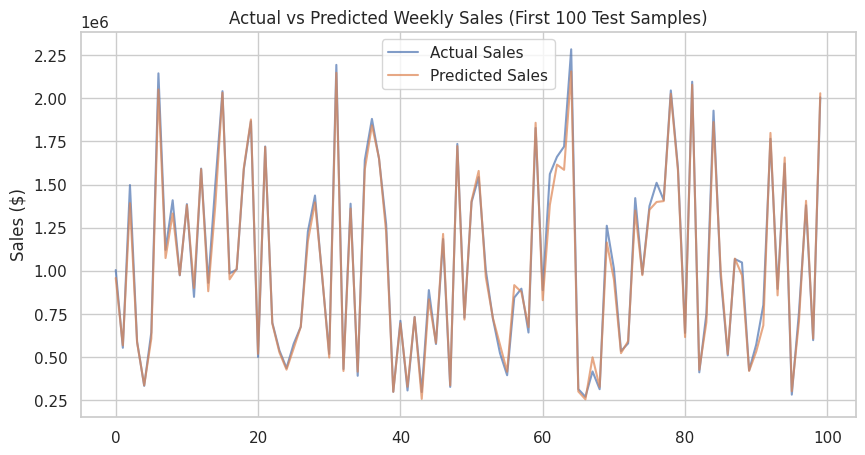

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Initialize and train the Ensemble Tree Regressor
print("Training Random Forest Regressor... (This may take a moment)")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. Generate predictions on the hold-out test set
predictions = rf_model.predict(X_test)

# 3. Calculate Performance Metrics
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("\n=== Forecasting Model Evaluation ===")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# 4. Visualizing True vs Predicted Sales for a sample
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:100], label='Actual Sales', alpha=0.7)
plt.plot(predictions[:100], label='Predicted Sales', alpha=0.7)
plt.title('Actual vs Predicted Weekly Sales (First 100 Test Samples)')
plt.ylabel('Sales ($)')
plt.legend()
plt.show()

In [20]:
import joblib

# 1. Save the Forecasting Model (Walmart)
joblib.dump(rf_model, 'sales_forecasting_rf_model.pkl')

# 2. Save the Clustering Model (Online Retail)
joblib.dump(kmeans_final, 'customer_segmentation_kmeans_model.pkl')

print("=== Models Saved Successfully ===")
print("Look in the file explorer pane on the left side of your Colab screen.")
print("You can right-click the .pkl files and select 'Download' to save them to your local machine for submission.")


=== Models Saved Successfully ===
Look in the file explorer pane on the left side of your Colab screen.
You can right-click the .pkl files and select 'Download' to save them to your local machine for submission.


In [21]:
import datetime

# 1. Identify the absolute last date in the Walmart dataset
last_date = walmart_df['Date'].max()

# 2. Generate the next 12 weekly dates
future_dates = [last_date + datetime.timedelta(weeks=i) for i in range(1, 13)]

# 3. Construct the future feature matrix for all stores
future_records = []
stores = walmart_df['Store'].unique()

for date in future_dates:
    for store in stores:
        # Fetch the most recent macroeconomic data for this specific store
        last_store_info = walmart_df[walmart_df['Store'] == store].iloc[-1]

        future_records.append({
            'Store': store,
            'Date': date,
            'Holiday_Flag': 0, # Defaulting to 0; can be mapped to 1 if dates align with holidays
            'Temperature': last_store_info['Temperature'],
            'Fuel_Price': last_store_info['Fuel_Price'],
            'CPI': last_store_info['CPI'],
            'Unemployment': last_store_info['Unemployment'],
            'Year': date.year,
            'Month': date.month,
            'WeekOfYear': date.isocalendar().week
        })

future_df = pd.DataFrame(future_records)

# 4. Predict future sales using the trained Random Forest model
future_features = future_df[['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'WeekOfYear']]
future_df['Predicted_Weekly_Sales'] = rf_model.predict(future_features)

print("=== Next 12 Weeks Forecast Complete ===")
print(f"Total future predictions generated: {future_df.shape[0]}")
display(future_df[['Store', 'Date', 'Predicted_Weekly_Sales']].head(10))

# 5. Save the forecast to a CSV for your records
future_df.to_csv('walmart_12_week_forecast.csv', index=False)

=== Next 12 Weeks Forecast Complete ===
Total future predictions generated: 540


,Store,Date,Predicted_Weekly_Sales
0,1,2012-11-02,1.587192e+06
1,10,2012-11-02,1.879826e+06
2,37,2012-11-02,5.260756e+05
3,17,2012-11-02,9.297522e+05
4,30,2012-11-02,4.225956e+05
5,25,2012-11-02,7.210413e+05
6,22,2012-11-02,1.001898e+06
7,23,2012-11-02,1.271149e+06
8,24,2012-11-02,1.232079e+06
9,19,2012-11-02,1.230942e+06
